In [16]:
import numpy as np
import torch
import torchvision
from torchvision import transforms, models

In [2]:
print("PyTorch version: ", torch.__version__)
print("TorchVision version: ", torchvision.__version__)

PyTorch version:  2.13.0+cpu
TorchVision version:  0.28.0+cpu


In [3]:
use_pretrained = True
net = models.vgg16(pretrained=use_pretrained)
net.eval()
net 

c:\Users\Hello\miniconda3\envs\min_ds-env\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Hello\miniconda3\envs\min_ds-env\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Hello/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [01:14<00:00, 7.42MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Ở đây chúng ta thấy nó có rất nhiều lớp nhưng tại sao lại là vgg16, thì có nghĩ là nó có 16 lớp là chỉ tính các lớp Conv2d và Linear thôi

In [20]:
class BaseTransform():
    def __init__(self, resize, mean, std):
        self.base_transform = transforms.Compose([
            transforms.Resize(resize),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ])

    def __call__(self, img):
        return self.base_transform(img)

In [5]:
!ls


dog.avif
dog.jpg
load_vgg.ipynb
model_nn_modules.ipynb
model_nn_sequence.ipynb


In [6]:
! mkdir data
! mv dog.* data

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

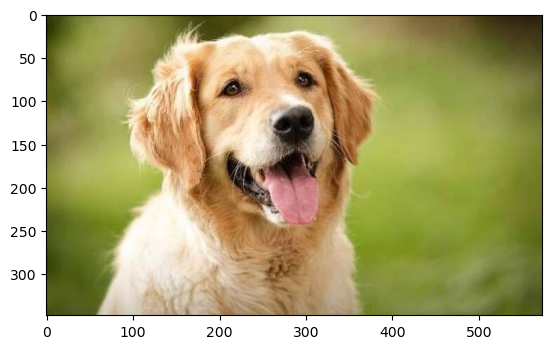

In [13]:
image_file_path = "./data/dog.jpg"
image = Image.open(image_file_path)

plt.imshow(image);

In [14]:
resize = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

In [21]:
Transform = BaseTransform(resize, mean, std) # Tao ra transform de chuan hoa anh dau vao
img_transformed = Transform(image)
#plt.imshow(img_transformed.permute(1, 2, 0)); # Chuyen anh tu (C, H, W) sang (H, W, C) de hien thi

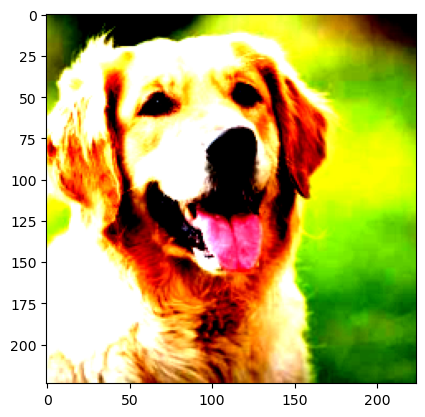

In [22]:
img_transformed = img_transformed.numpy().transpose((1, 2, 0)) # Chuyen anh tu (C, H, W) sang (H, W, C) de hien thi
img_transformed = np.clip(img_transformed, 0, 1) # Cat gia tri anh ve [0, 1] 
plt.imshow(img_transformed);